In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv("", sep=None, engine="python")

y = df["is_alarm"]
X = df.drop(["is_alarm"], axis=1)
X = X.select_dtypes(include=[np.number])  

data = pd.concat([X, y], axis=1).dropna()
X = data.drop("is_alarm", axis=1)
y = data["is_alarm"]

print("Data size before balancing:", X.shape)

Data size before balancing: (21625, 30)


In [3]:

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
y_resampled = y_resampled.astype(int)

y_resampled.value_counts()

is_alarm
0    20980
1    20980
Name: count, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)
print("X_train Shape:", X_train.shape)
print("X_test size:", X_test.shape)

X_train Shape: (33568, 30)
X_test size: (8392, 30)


In [5]:
model_cb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=7,
    eval_metric='Accuracy',
    random_seed=42,
    verbose=50
)


model_cb.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.7785689	test: 0.7840801	best: 0.7840801 (0)	total: 78.3ms	remaining: 23.4s
50:	learn: 0.9558508	test: 0.9554337	best: 0.9554337 (48)	total: 600ms	remaining: 2.93s
100:	learn: 0.9735462	test: 0.9731888	best: 0.9735462 (98)	total: 1.14s	remaining: 2.25s
150:	learn: 0.9812619	test: 0.9806959	best: 0.9806959 (150)	total: 1.67s	remaining: 1.64s
200:	learn: 0.9839728	test: 0.9823642	best: 0.9824833 (183)	total: 2.17s	remaining: 1.07s
250:	learn: 0.9856411	test: 0.9829600	best: 0.9830791 (236)	total: 2.66s	remaining: 519ms
299:	learn: 0.9868625	test: 0.9829600	best: 0.9833174 (288)	total: 3.13s	remaining: 0us

bestTest = 0.9833174452
bestIteration = 288

Shrink model to first 289 iterations.


CatBoostClassifier(depth=7, eval_metric='Accuracy', iterations=300, learning_rate=0.1, random_seed=42, verbose=50)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      4120
           1       0.97      1.00      0.98      4272

    accuracy                           0.98      8392
   macro avg       0.98      0.98      0.98      8392
weighted avg       0.98      0.98      0.98      8392


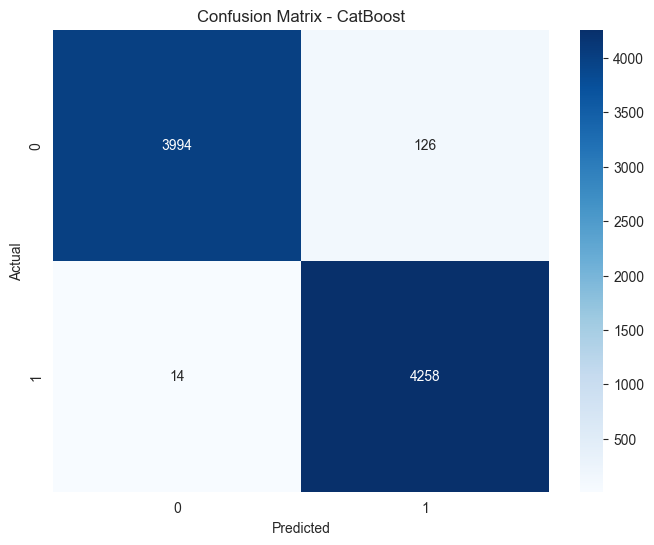

In [6]:

y_pred = model_cb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost")
plt.show()

In [7]:
import pickle

with open("Catboost_F.pkl", "wb") as f:
    pickle.dump(model_cb, f)



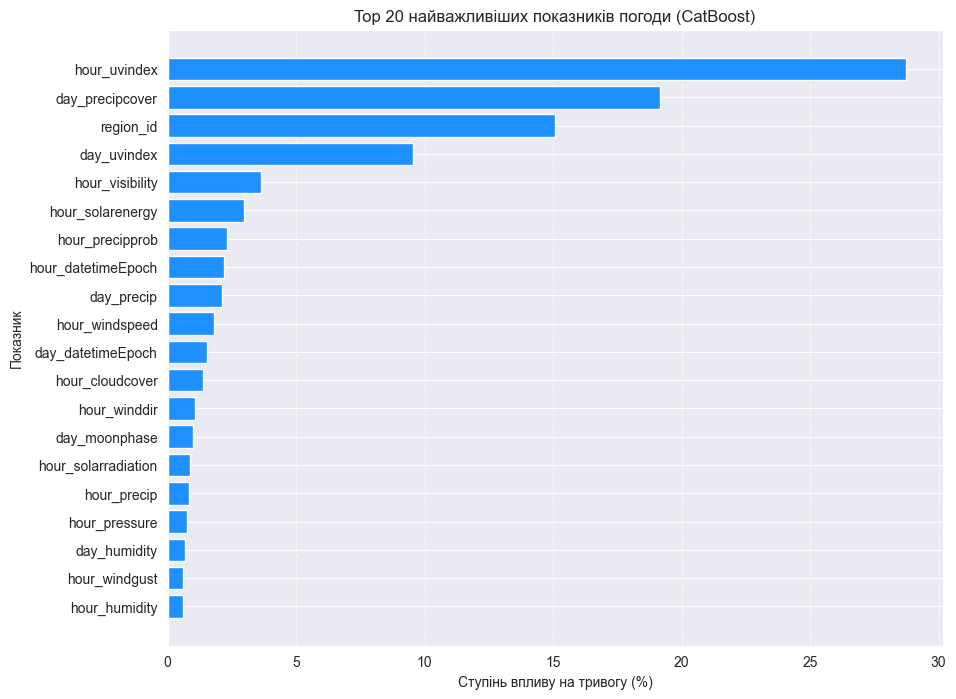

In [8]:
#Графік Top 20 Features
feature_importances = model_cb.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
top_20_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_20_df['Feature'][::-1], top_20_df['Importance'][::-1], color='dodgerblue')
plt.title('Top 20 найважливіших показників погоди (CatBoost)')
plt.xlabel('Ступінь впливу на тривогу (%)')
plt.ylabel('Показник')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()